In [ ]:
import os
import pickle
import sys
sys.path.append(os.path.join(os.getcwd(), "metient/jupyter_notebooks/lineage_tracing"))
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gzip
from scipy.io import mmread, mmwrite
import scanpy as sc
from scipy.stats import ttest_ind
from sklearn.metrics.pairwise import cosine_similarity
import metient as met
from metient.util.globals import *
output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"
cass_results_dir = os.path.join(DATA_DIR, "cassiopeia_outputs")
metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")

In [9]:

def find_path_to_root(A, target_node):
    A = A.coalesce()
    row_indices = A.indices()[0]
    col_indices = A.indices()[1]

    path = [target_node]  # Start from the target node
    current_node = target_node

    while True:
        # Find the parent of the current node (look for incoming edges in the column)
        parents = row_indices[col_indices == current_node].tolist() 

        if len(parents) == 0:
            break  # No parent means we've reached the root

        assert(len(parents)==1)

        parent = parents[0]
        # Update the current node to its parent
        current_node = parent
        path.append(current_node)

    # Reverse the path to go from root to target
    return path[::-1]

# Function to count label changes along the path from root to target node
def count_label_changes(A, L, target, node_info):
    
    path = find_path_to_root(A,target)
    # Count label changes
    label_changes = 0
    for i in range(1, len(path)):
        current_node = path[i]
        previous_node = path[i - 1]
        
        # Compare the labels of the current and previous nodes
        if isinstance(L, dict):
            previous_node_label = L[node_info[previous_node][0][0]]
            current_node_label = L[node_info[current_node][0][0]]
            if previous_node_label != current_node_label:
                label_changes += 1
        else:
            if not np.array_equal(L[:, current_node], L[:, previous_node]):
                label_changes += 1
    
    return label_changes

def find_metient_first_parent_with_diff_label(A, V, ordered_sites, node_idx):
    A = A.coalesce()
    # Get the COO representation of the sparse tensor
    row_indices = A.indices()[0]
    col_indices = A.indices()[1]

    # Use boolean indexing to find the parent nodes
    parent_indices = row_indices[col_indices == node_idx].tolist() 

    # We've reached the root
    if len(parent_indices)==0: 
        return ordered_sites[np.argmax(V[:,node_idx])]
    assert(len(parent_indices)==1)
    parent = parent_indices[0]

    # Base case
    if np.argmax(V[:,parent]) !=  np.argmax(V[:,node_idx]):
        return ordered_sites[np.argmax(V[:,parent])]
    return find_metient_first_parent_with_diff_label(A, V, ordered_sites, parent)

def find_fitch_count_first_parent_with_diff_label(A, V, ordered_sites, node_idx, node_info):
    A = A.coalesce()
    # Get the COO representation of the sparse tensor
    row_indices = A.indices()[0]
    col_indices = A.indices()[1]

    # Use boolean indexing to find the parent nodes
    parent_indices = row_indices[col_indices == node_idx].tolist() 

    # We've reached the root
    if len(parent_indices)==0: 
        children_indices = col_indices[row_indices == node_idx].tolist()
        assert(len(children_indices)==1)
        return V[node_info[children_indices[0]][0][0]]
    
    assert(len(parent_indices)==1)
    parent = parent_indices[0]
    parent_label = V[node_info[parent][0][0]]
    node_label = V[node_info[node_idx][0][0]]
    # Base case
    if parent_label != node_label:
        return parent_label
    return find_fitch_count_first_parent_with_diff_label(A, V, ordered_sites, parent, node_info)

def extract_fitch_count_tissue_of_origin(ordered_sites, A, V, node_info):
    # Add the fake "germline" root which we use for Metient
    V['primary'] = 'LL'
    for node in node_info:
        if node_info[node][1] == True: # is a leaf node
            originating_tissue = find_fitch_count_first_parent_with_diff_label(A,V,ordered_sites,node,node_info)
            bc = node_info[node][0][0]
            final_tissue = node_info[node][0][1]
            num_label_changes = count_label_changes(A, V, node, node_info)
            yield bc, originating_tissue, final_tissue, num_label_changes

def extract_metient_tissue_of_origin(ordered_sites, A, V, node_info):
    for node in node_info:
        if node_info[node][1] == True: # is a leaf node
            originating_tissue = find_metient_first_parent_with_diff_label(A,V,ordered_sites,node)
            bc = node_info[node][0][0]
            final_tissue = node_info[node][0][1]
            num_label_changes = count_label_changes(A, V, node, node_info)
            yield bc, originating_tissue, final_tissue, num_label_changes
            

In [ ]:
import numpy.core.numeric

# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")

data = {
    "clone": [],
    "bc": [],
    "method": [],
    "tissue of origin": [],
    "final tissue": [],
    "num label changes": [],
}

with open(os.path.join(cass_results_dir,"vanilla_greedy_cas_random_min_mig_history.pkl") ,"rb") as f:
    fitch_count_histories = pickle.load(f)
        
for clone in clones:
    print("\nClone", clone)

    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
        
    ordered_sites = pckl[OUT_SITES_KEY]
    A = met.adjacency_matrix_from_parents(pckl[OUT_PARENTS_KEY][0])
    V = pckl[OUT_LABElING_KEY][0]
    node_info = pckl[OUT_IDX_LABEL_KEY][0]

    for t in extract_metient_tissue_of_origin(ordered_sites, A, V, node_info):
        bc, originating_tissue, final_tissue, num_label_changes = t
        data["clone"].append(clone)
        data["method"].append("Metient")
        data["bc"].append(bc)
        data["tissue of origin"].append(originating_tissue)
        data["final tissue"].append(final_tissue)
        data["num label changes"].append(num_label_changes)

    for t in extract_fitch_count_tissue_of_origin(ordered_sites, A, fitch_count_histories[clone], node_info):
        bc, originating_tissue, final_tissue, num_label_changes = t
        data["clone"].append(clone)
        data["method"].append("FitchCount")
        data["bc"].append(bc)
        data["tissue of origin"].append(originating_tissue)
        data["final tissue"].append(final_tissue)
        data["num label changes"].append(num_label_changes)

df = pd.DataFrame(data)
    

95 clones

Clone 7

Clone 8

Clone 9

Clone 10

Clone 11

Clone 12

Clone 13

Clone 14

Clone 15

Clone 16

Clone 17

Clone 18

Clone 19

Clone 20

Clone 21

Clone 22

Clone 23

Clone 24

Clone 25

Clone 26

Clone 27

Clone 28

Clone 30

Clone 31

Clone 32

Clone 33

Clone 34

Clone 35

Clone 36

Clone 37

Clone 38

Clone 39

Clone 40

Clone 41

Clone 42

Clone 43

Clone 44

Clone 45

Clone 47

Clone 48

Clone 49

Clone 50

Clone 51

Clone 52

Clone 53

Clone 54

Clone 55

Clone 56

Clone 57

Clone 58

Clone 59

Clone 60

Clone 61

Clone 62

Clone 63

Clone 64

Clone 65

Clone 66

Clone 67

Clone 68

Clone 69

Clone 70

Clone 71

Clone 72

Clone 73

Clone 74

Clone 75

Clone 76

Clone 77

Clone 79

Clone 80

Clone 81

Clone 82

Clone 83

Clone 84

Clone 85

Clone 86

Clone 87

Clone 88

Clone 89

Clone 90

Clone 91

Clone 92

Clone 93

Clone 95

Clone 96

Clone 97

Clone 98

Clone 99

Clone 100


### Load gene expression data

In [ ]:
allele_table = pd.read_csv("https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM4905nnn/GSM4905334/suppl/GSM4905334_alleleTable.5k.txt.gz", sep='\t',
                           usecols = ['cellBC', 'intBC', 'r1', 'r2', 'r3', 'allele', 'LineageGroup', 'sampleID', 'readCount', 'UMI'])

# These files can be downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM4905335
mtx_file = os.path.join(DATA_DIR, "gene_expression", "GSM4905335_matrix.5k.mtx")
matrix = mmread(mtx_file).tocsc()  # Using a compressed sparse column format to handle large data
barcode_file = os.path.join(DATA_DIR, "gene_expression", "GSM4905335_barcodes.5k.tsv")
gene_file = os.path.join(DATA_DIR, "gene_expression", "GSM4905335_genes.5k.tsv")

barcodes = pd.read_csv(barcode_file, header=None, sep='\t')
genes = pd.read_csv(gene_file, header=None, sep='\t')

# Save subsetted matrix files for each clone (for computational ease)
for clone in clones:
    cell_barcodes = allele_table[allele_table['LineageGroup']==clone]['cellBC'].unique()
    
    desired_indices = barcodes[barcodes[0].isin(cell_barcodes)].index.tolist()
    filtered_matrix = matrix[:, desired_indices]
    mmwrite(os.path.join(DATA_DIR, "gene_expression", f"clone_{clone}_matrix.5k.mtx"), filtered_matrix)

In [19]:

cell_to_similaries = {
    "Barcode":[],
    "Metient origin tissue":[],
    "FitchCount origin tissue":[],
    "Metient origin tissue sim":[],
    "FitchCount origin tissue sim":[],
    "Destination tissue sim":[],
    # "Cells in tissues w/o same origin (Metient) or dest sim":[],
    # "Cells in tissues w/o same origin (FitchCount) or dest sim":[],
    "Cells w/ same origin (Metient) and dest sim":[],
    "Cells w/o same origin (Metient) and dest sim":[],
    "Cells w/ same origin (FitchCount) and dest sim":[],
    "Cells w/o same origin (FitchCount) and dest sim":[],
}

def get_cos_similarity_tissues(pairwise_sim_matrix, tissue_to_obs_names, tissues_of_int, cell):

    # cells_in_tissue_excluding_cell_of_int = adata[(adata.obs['cell_tissue'].isin(tissues_of_int)) & (~adata.obs_names.isin([cell]))]
    cells_in_tissues_of_interest = [cell for tissue in tissues_of_int if tissue in tissue_to_obs_names for cell in tissue_to_obs_names[tissue]]
    cells_in_tissues_excluding_cell_of_int = set(cells_in_tissues_of_interest) - set([cell])

    cells_to_include_indices = [obs_name_to_idx[name] for name in cells_in_tissues_excluding_cell_of_int if name in obs_name_to_idx]
    if len(cells_to_include_indices) == 0: return np.nan
    # group_data = cells_in_tissue_excluding_cell_of_int.X
    # cos_sim = cosine_similarity([cell_expression], group_data)
    
    similarities = pairwise_sim_matrix[obs_name_to_idx[cell], cells_to_include_indices]
    return np.mean(similarities)

def get_cos_similarity_cells(pairwise_sim_matrix, obs_name_to_idx, cells_to_include, cell):

    #cells_excluding_cell_of_int = adata[(~adata.obs_names.isin([cell])) & (adata.obs_names.isin(cells_to_include))]
    cells_to_include = set(cells_to_include) - set([cell])
    cells_to_include_indices = [obs_name_to_idx[name] for name in cells_to_include if name in obs_name_to_idx]
    if len(cells_to_include_indices) == 0: return np.nan
    # group_data = cells_excluding_cell_of_int.X
    # cos_sim = cosine_similarity([cell_expression], group_data)
    similarities = pairwise_sim_matrix[obs_name_to_idx[cell], cells_to_include_indices]
    return np.mean(similarities)

def compute_pairwise_cosine_similarity(adata):
    """
    Compute the pairwise cosine similarity matrix for all cells in the dataset.
    """
    # Ensure data is in dense format for cosine similarity calculation
    data_matrix = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
    
    # Compute the pairwise cosine similarity matrix
    pairwise_sim_matrix = cosine_similarity(data_matrix)
    
    return pairwise_sim_matrix

for clone in clones:
    print("Clone", clone)
    
    cell_barcodes = allele_table[allele_table['LineageGroup']==clone]['cellBC'].unique()
    desired_indices = barcodes[barcodes[0].isin(cell_barcodes)].index.tolist()
    filtered_barcodes = barcodes.iloc[desired_indices]

    # Load the filtered matrix from earlier steps
    adata = sc.read_mtx(os.path.join(DATA_DIR, "gene_expression", f"clone_{clone}_matrix.5k.mtx"))
    adata = adata.transpose()

    # Assign barcodes as observations and genes as variables
    adata.obs_names = filtered_barcodes[0].values  # Assign barcodes to the cells
    adata.var_names = genes[0].values     # Assign genes to the variables

    # Preprocess the data
    sc.pp.filter_genes(adata, min_cells=3)    # Filter genes expressed in fewer than 3 cells
    # Normalize by median UMI
    total_umis_per_cell = np.ravel(adata.X.sum(axis=1))  # Axis=1 sums across rows for each cell
    median_umis = np.median(total_umis_per_cell)  # Use np.median to compute the median
    adata.X = adata.X / median_umis
    sc.pp.log1p(adata)  # Log-transform the data

    cell_bc_to_tissue = {x:x.split(".")[0] for x in list(adata.obs_names)}
    adata.obs['cell_tissue'] = adata.obs_names.map(cell_bc_to_tissue)
    obs_name_to_idx = {name: idx for idx, name in enumerate(adata.obs_names)}
    tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()
    all_tissues = list(adata.obs['cell_tissue'].unique())

    pairwise_sim_matrix = compute_pairwise_cosine_similarity(adata)

    for cell in adata.obs_names:
        cell_df = df[df['bc']==cell]
        # We need to get the cosine similarity between the cell's expression and:
        # 1. Its final tissue
        # 2. Cells in Metient's predicted tissue of origin (mean expression)
        # 3. Cells in FitchCount's predicted tissue of origin (mean expression)
        metient_origin_tissue = cell_df[cell_df['method']=='Metient']['tissue of origin'].item()
        fitchcount_origin_tissue = cell_df[cell_df['method']=='FitchCount']['tissue of origin'].item()
        cell_expression = adata[cell].X.toarray().flatten()  # Get the expression of the specific cell
        met_origin_tissue_sim = get_cos_similarity_tissues(pairwise_sim_matrix, tissue_to_obs_names, [metient_origin_tissue], cell )
        fitchcount_origin_tissue_sim = get_cos_similarity_tissues(pairwise_sim_matrix, tissue_to_obs_names, [fitchcount_origin_tissue], cell)
        
        final_tissue = cell_bc_to_tissue[cell]
        final_tissue_sim = get_cos_similarity_tissues(pairwise_sim_matrix, tissue_to_obs_names, [final_tissue], cell)

        primary_sim = get_cos_similarity_tissues(pairwise_sim_matrix, tissue_to_obs_names, ['LL'], cell)

        # Get the cos similary between this cell and cells NOT in its tissue of origin (Metient predicted) or destination
        cell_to_similaries['Barcode'].append(cell)
        cell_to_similaries['Metient origin tissue'].append(metient_origin_tissue)
        cell_to_similaries['FitchCount origin tissue'].append(fitchcount_origin_tissue)
        cell_to_similaries['Metient origin tissue sim'].append(met_origin_tissue_sim)
        cell_to_similaries['FitchCount origin tissue sim'].append(fitchcount_origin_tissue_sim)
        cell_to_similaries['Destination tissue sim'].append(final_tissue_sim)


        cells_same_met_orig_dest = list(df[(df['clone']==clone)&(df['tissue of origin']==metient_origin_tissue)&(df['final tissue']==final_tissue)]['bc'].unique())
        cell_to_similaries['Cells w/ same origin (Metient) and dest sim'].append(get_cos_similarity_cells(pairwise_sim_matrix, obs_name_to_idx, cells_same_met_orig_dest, cell))
        not_cells_same_met_orig_dest = list(df[(df['clone']==clone)& (~df['bc'].isin(cells_same_met_orig_dest))]['bc'].unique())
        cell_to_similaries['Cells w/o same origin (Metient) and dest sim'].append(get_cos_similarity_cells(pairwise_sim_matrix, obs_name_to_idx, not_cells_same_met_orig_dest, cell))

        cells_same_fitch_orig_dest = list(df[(df['clone']==clone)&(df['tissue of origin']==fitchcount_origin_tissue)&(df['final tissue']==final_tissue)]['bc'].unique())
        cell_to_similaries['Cells w/ same origin (FitchCount) and dest sim'].append(get_cos_similarity_cells(pairwise_sim_matrix, obs_name_to_idx, cells_same_fitch_orig_dest, cell))
        not_cells_same_fitch_orig_dest = list(df[(df['clone']==clone)& (~df['bc'].isin(cells_same_fitch_orig_dest))]['bc'].unique())
        cell_to_similaries['Cells w/o same origin (FitchCount) and dest sim'].append(get_cos_similarity_cells(pairwise_sim_matrix, obs_name_to_idx, not_cells_same_fitch_orig_dest, cell))

cell_to_sim_df = pd.DataFrame(cell_to_similaries)


Clone 12


/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()


Clone 13


/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()


Clone 14


...

/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()
/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()


Clone 99


/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()


Clone 100


/tmp/ipykernel_1389021/3290011033.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tissue_to_obs_names = adata.obs.groupby('cell_tissue').apply(lambda x: x.index.tolist()).to_dict()


Method Metient
num orig_dest_values 1192
num all_other_tissue_values 1192
Variances are approximately equal: True  P-value: 0.1632
t_stat 19.72354059594384
p value 3.709670067452005e-75
Mean difference: 0.017011103297336735
Std deviation of differences: 0.029764835328649278
chohens_d 0.5712770147224596


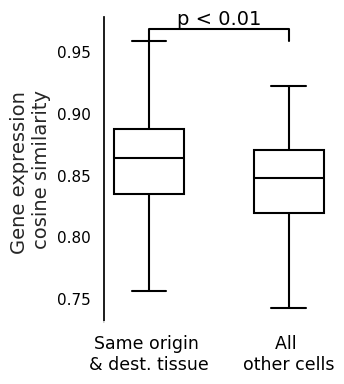

Method FitchCount
num orig_dest_values 1090
num all_other_tissue_values 1090
Variances are approximately equal: False  P-value: 0.0007
t_stat 18.855325037949658
p value 7.554556653558713e-69
Mean difference: 0.020240098472735255
Std deviation of differences: 0.0354235871434701
chohens_d 0.5711113279273221


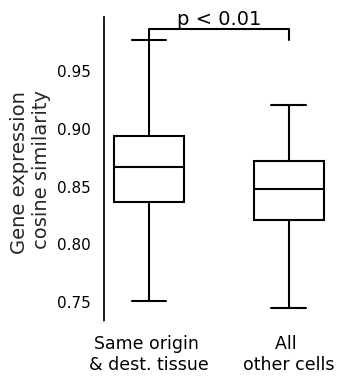

In [20]:
from scipy import stats


for method in ['Metient', 'FitchCount']:
    print("Method", method)
    # List 1: All values from 'Metient origin tissue sim' and 'Destination tissue sim' columns
    orig_dest_values = []
    all_other_tissue_values = []
    for _,row in cell_to_sim_df.iterrows():
        if row['Metient origin tissue'] == row['FitchCount origin tissue']: 
            continue
        # same_x = (float(row[f'{method} origin tissue sim'])+float(row['Destination tissue sim']))/2
        # diff_x = float(row[f'All other tissues sim ({method})'])

        same_x = float(row[f'Cells w/ same origin ({method}) and dest sim'])
        diff_x = float(row[f'Cells w/o same origin ({method}) and dest sim'])
        if np.isnan(same_x) or np.isnan(diff_x):
            continue
        orig_dest_values.append(same_x)
        all_other_tissue_values.append(diff_x)
    
    print("num orig_dest_values", len(orig_dest_values))
    print("num all_other_tissue_values", len(all_other_tissue_values))
    stat, p_value = stats.levene(orig_dest_values, all_other_tissue_values, center='median')
    print(f"Variances are approximately equal: {p_value>0.05}  P-value: {p_value:.4f}")
        
    # metient_values = pd.concat([cell_to_sim_df[f'{method} origin tissue sim'], cell_to_sim_df['Destination tissue sim']]).values.tolist()
    # all_other_metient_values = cell_to_sim_df[f'All other tissues sim ({method})'].explode().values.tolist()
    data = {
        'Cos. sim.': orig_dest_values + all_other_tissue_values,  # Concatenate both lists
        'Category': ['Same origin \n& dest. tissue'] * len(orig_dest_values) + ['All \nother cells'] * len(all_other_tissue_values)
    }
    df_plot = pd.DataFrame(data)
    t_stat, p_value = stats.ttest_rel(orig_dest_values, all_other_tissue_values)
    print("t_stat", t_stat)
    print("p value", p_value)
 
    diffs = [o - a for o, a in zip(orig_dest_values, all_other_tissue_values)]
    print("Mean difference:", np.mean(diffs))
    print("Std deviation of differences:", np.std(diffs))
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, ddof=1)  # ddof=1 for sample standard deviation
    cohens_d = mean_diff / std_diff
    print("chohens_d", cohens_d)

    # Set the Seaborn style for aesthetics
    sns.set(style="whitegrid")

    # Create the boxplot
    plt.figure(figsize=(3.6, 4))

    # Remove gridlines
    plt.grid(False)

    # Remove top and right axes (spines)
    sns.despine()
    sns.set(style="white")
    ax = sns.boxplot(x='Category', y='Cos. sim.', data=df_plot, width=0.5, showfliers=False,
                    boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.5),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    medianprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5))

    # Make axes black
    ax.tick_params(colors='black', which='both')  # Color tick labels and ticks black
    ax.spines['bottom'].set_color('white')  # Bottom axis spine
    ax.spines['left'].set_color('black')  # Left axis spine
    # Add title and labels
    plt.xlabel('', fontsize=12)
    plt.ylabel('Gene expression \ncosine similarity', fontsize=14)
    plt.xticks(fontsize=12.5, rotation=0)

    # Add annotation with p-value
    y_max = df_plot['Cos. sim.'].max() * 1.01  # Slightly higher than the max y-value for space
    x1, x2 = 0, 1  # Positions of the two categories
    h = 0.01  # Height of the line connecting the boxes
    col = 'black'
    plt.plot([x1, x1, x2, x2], [y_max - h, y_max, y_max, y_max - h], lw=1.5, c=col)
    # Add the p-value as text
    
    p_text = "p < 0.01" if p_value < 0.001 else f"{p_text:.3e}"
    plt.text((x1 + x2) * 0.5, y_max, p_text, ha='center', va='bottom', color=col, fontsize=14)
    plt.ylim(top=y_max + 0.01)  # Adjust the top limit of the y-axis

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{method}_origin_or_des_tissue_vs_other_tissue_gene_exp.png"), dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.show()
    plt.close()
